# Important Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

# Collect or download a large text corpus

In [2]:
df=pd.read_csv(r"C:\Users\kd940\Downloads\archive\emails.csv")
df.head()

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [3]:
print(df.loc[0, 'message'])

Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>
Date: Mon, 14 May 2001 16:39:00 -0700 (PDT)
From: phillip.allen@enron.com
To: tim.belden@enron.com
Subject: 
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: Tim Belden <Tim Belden/Enron@EnronXGate>
X-cc: 
X-bcc: 
X-Folder: \Phillip_Allen_Jan2002_1\Allen, Phillip K.\'Sent Mail
X-Origin: Allen-P
X-FileName: pallen (Non-Privileged).pst

Here is our forecast

 


In [4]:
from email import message_from_string
def extract_email(text):
    msg = message_from_string(text)

    return pd.Series({
        'Message_ID': msg['Message-ID'],
        'Date': msg['Date'],
        'From': msg['From'],
        'To': msg['To'],
        'Cc': msg['Cc'],
        'Bcc': msg['Bcc'],
        'Subject': msg['Subject'],
        'Body': msg.get_payload()
    })


In [5]:
emails = df.loc[:9999, 'message'].apply(extract_email)
emails.head()

,Message_ID,Date,From,To,Cc,Bcc,Subject,Body
0,<18782981.1075855378110.JavaMail.evans@thyme>,"Mon, 14 May 2001 16:39:00 -0700 (PDT)",phillip.allen@enron.com,tim.belden@enron.com,NaN,NaN,,Here is our forecast\n\n
1,<15464986.1075855378456.JavaMail.evans@thyme>,"Fri, 4 May 2001 13:51:00 -0700 (PDT)",phillip.allen@enron.com,john.lavorato@enron.com,NaN,NaN,Re:,Traveling to have a business meeting takes the...
2,<24216240.1075855687451.JavaMail.evans@thyme>,"Wed, 18 Oct 2000 03:00:00 -0700 (PDT)",phillip.allen@enron.com,leah.arsdall@enron.com,NaN,NaN,Re: test,test successful. way to go!!!
3,<13505866.1075863688222.JavaMail.evans@thyme>,"Mon, 23 Oct 2000 06:13:00 -0700 (PDT)",phillip.allen@enron.com,randall.gay@enron.com,NaN,NaN,,"Randy,\n\n Can you send me a schedule of the s..."
4,<30922949.1075863688243.JavaMail.evans@thyme>,"Thu, 31 Aug 2000 05:07:00 -0700 (PDT)",phillip.allen@enron.com,greg.piper@enron.com,NaN,NaN,Re: Hello,Let's shoot for Tuesday at 11:45.


In [6]:
emails.duplicated().sum()

np.int64(0)

In [7]:
import re
import string
import contractions
import nltk

In [8]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
emails.isna().sum()

Message_ID       0
Date             0
From             0
To             329
Cc            9075
Bcc           9075
Subject          0
Body             0
dtype: int64

In [10]:
emails.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Message_ID  10000 non-null  str  
 1   Date        10000 non-null  str  
 2   From        10000 non-null  str  
 3   To          9671 non-null   str  
 4   Cc          925 non-null    str  
 5   Bcc         925 non-null    str  
 6   Subject     10000 non-null  str  
 7   Body        10000 non-null  str  
dtypes: str(8)
memory usage: 18.8 MB


In [11]:
emails['Date']=pd.to_datetime(emails['Date'],utc=True,errors='coerce')

C:\Users\kd940\AppData\Local\Temp\ipykernel_284480\4060065060.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  emails['Date']=pd.to_datetime(emails['Date'],utc=True,errors='coerce')


In [12]:
emails['Date'] = emails['Date'].dt.date

In [13]:
emails['Date']=pd.to_datetime(emails['Date'])

In [14]:
emails=emails.drop(columns=['Cc','Bcc'])
emails['To']=emails['To'].fillna('Unknown')

In [15]:
emails.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   Message_ID  10000 non-null  str          
 1   Date        10000 non-null  datetime64[s]
 2   From        10000 non-null  str          
 3   To          10000 non-null  str          
 4   Subject     10000 non-null  str          
 5   Body        10000 non-null  str          
dtypes: datetime64[s](1), str(5)
memory usage: 18.2 MB


# NLP preprocessing: tokenisation, lowercasing, punctuation removal, stopword removal

In [16]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()                          # Lowercase
    text = re.sub(r'[^\w\s]', '', text)               # Remove punctuation
    text = re.sub(r'\d+', '', text)                   # Remove numbers
    tokens = word_tokenize(text)                      # Tokenization
    tokens = [word for word in tokens if word not in stop_words]  # Stopword removal
    return " ".join(tokens)

emails['Clean_Text'] = emails['Body'].apply(preprocess)

In [17]:
emails['Clean_Text']

0                                                forecast
1       traveling business meeting takes fun trip espe...
2                                  test successful way go
3       randy send schedule salary level everyone sche...
4                                      lets shoot tuesday
                              ...                        
9995    shes pretty sexy huh getting together talk eur...
9996                             copied idea screwed name
9997    forwarded eric basshouect troy klussmann eric ...
9998                                            buy enron
9999    yea thanks reminding bday nearly forgot ha ha ...
Name: Clean_Text, Length: 10000, dtype: str

In [18]:
text_data = emails['Clean_Text']
text_data = text_data[text_data.str.strip() != '']

In [19]:
text_data[:20]

0                                              forecast
1     traveling business meeting takes fun trip espe...
2                                test successful way go
3     randy send schedule salary level everyone sche...
4                                    lets shoot tuesday
5             greg either next tuesday thursday phillip
6     please cc following distribution list updates ...
7                                               morning
8     login pallen pw kedavis dont think required is...
9     forwarded phillip k allenhouect pm buckner buc...
10    mr buckner delivered gas behind san diego enro...
11    lucy rentrolls open save rentroll folder follo...
12    forwarded phillip k allenhouect pm richard bur...
13    forwarded phillip k allenhouect pm richard bur...
14    dave names west desk members category originat...
15                           paula million fine phillip
16    forwarded phillip k allenhouect pm enron north...
17    tim mike grigsby problems accessing west p

In [20]:
corpus = " ".join(text_data)

# Autocomplete implementation: build a frequency-based n-gram model (bigram or trigram) that predicts the next word given a prefix

In [21]:
tokens = corpus.split()
print(tokens[:20])

['forecast', 'traveling', 'business', 'meeting', 'takes', 'fun', 'trip', 'especially', 'prepare', 'presentation', 'would', 'suggest', 'holding', 'business', 'plan', 'meetings', 'take', 'trip', 'without', 'formal']


In [22]:
from collections import Counter, defaultdict

trigrams = [
    (tokens[i], tokens[i+1], tokens[i+2])
    for i in range(len(tokens)-2)
]

trigram_counts = Counter(trigrams)
trigram_counts.most_common(10)

[(('image', 'image', 'image'), 1468),
 (('john', 'arnoldhouectect', 'cc'), 1015),
 (('pm', 'pm', 'pm'), 984),
 (('arnoldhouectect', 'cc', 'subject'), 938),
 (('phillip', 'k', 'allenhouect'), 889),
 (('forwarded', 'phillip', 'k'), 851),
 (('dow', 'jones', 'company'), 791),
 (('jones', 'company', 'inc'), 790),
 (('alignrightfont', 'size', 'fonttdtd'), 729),
 (('inc', 'rights', 'reserved'), 649)]

In [23]:
next_words = defaultdict(Counter)

for (word1, word2, word3), count in trigram_counts.items():
    next_words[(word1, word2)][word3] = count

In [24]:
trigram_counts.most_common(20)

[(('image', 'image', 'image'), 1468),
 (('john', 'arnoldhouectect', 'cc'), 1015),
 (('pm', 'pm', 'pm'), 984),
 (('arnoldhouectect', 'cc', 'subject'), 938),
 (('phillip', 'k', 'allenhouect'), 889),
 (('forwarded', 'phillip', 'k'), 851),
 (('dow', 'jones', 'company'), 791),
 (('jones', 'company', 'inc'), 790),
 (('alignrightfont', 'size', 'fonttdtd'), 729),
 (('inc', 'rights', 'reserved'), 649),
 (('arnold', 'john', 'subject'), 615),
 (('phillip', 'k', 'allenhouectect'), 614),
 (('original', 'message', 'arnold'), 586),
 (('pm', 'john', 'arnoldhouectect'), 581),
 (('message', 'arnold', 'john'), 579),
 (('arnold', 'john', 'sent'), 564),
 (('company', 'inc', 'rights'), 558),
 (('copyright', 'dow', 'jones'), 545),
 (('k', 'allenhouect', 'pm'), 513),
 (('fonttdtd', 'alignrightfont', 'size'), 495)]

In [25]:
next_words[('please', 'let')]

Counter({'know': 332,
         'us': 30,
         'cathy': 3,
         'e': 3,
         'debra': 3,
         'sara': 2,
         'pauline': 1,
         'errol': 1,
         'welfare': 1})

In [26]:
next_words[('look', 'forward')]

Counter({'working': 36,
         'hearing': 35,
         'seeing': 34,
         'continuing': 13,
         'speaking': 12,
         'response': 11,
         'opportunity': 11,
         'providing': 7,
         'meeting': 6,
         'talking': 5,
         'receiving': 5,
         'pm': 4,
         'pcc': 4,
         'spending': 4,
         'resolving': 4,
         'participation': 3,
         'serving': 3,
         'amazoniversaries': 3,
         'comments': 3,
         'confirmation': 3,
         'reviewing': 3,
         'even': 3,
         'discussing': 2,
         'staying': 2,
         'resolution': 2,
         'keeping': 2,
         'kelly': 2,
         'getting': 1,
         'welcoming': 1,
         'successful': 1,
         'active': 1,
         'reply': 1,
         'good': 1,
         'increased': 1,
         'bln': 1,
         'work': 1,
         'aring': 1,
         'sharing': 1})

In [27]:
def autocomplete(prefix, n=5):
    words = prefix.lower().split()
    
    if len(words) < 2:
        return "Please enter at least two words."
    
    last_two = (words[-2], words[-1])
    
    predictions = next_words.get(last_two)
    
    if not predictions:
        return "No prediction found."
    
    return predictions.most_common(n)

In [28]:
autocomplete("please let")

[('know', 332), ('us', 30), ('cathy', 3), ('e', 3), ('debra', 3)]

In [29]:
def predict_next_word(prefix):
    words = prefix.lower().split()
    
    if len(words) < 2:
        return None
    
    last_two = (words[-2], words[-1])
    
    predictions = next_words.get(last_two)
    
    if not predictions:
        return None
    
    return predictions.most_common(1)[0][0]

In [30]:
next_words[('thank', 'you')] # IT Gives Counter() Because "you" Not in corpus

Counter()

In [31]:
predict_next_word("please let")

'know'

# Test autocomplete on at least 10 input prefixes and display top 3 predictions per prefix

In [32]:
test_prefixes = [
    "please let",
    "let me",
    "look forward",
    "thank you",
    "i would",
    "we need",
    "as soon",
    "if you",
    "do not",
    "in order"
]
for prefix in test_prefixes:
    words = prefix.lower().split()
    
    if len(words) >= 2:
        key = (words[-2], words[-1])
        predictions = next_words[key].most_common(3)
        
        print(f"\nPrefix: '{prefix}'")
        
        for word, count in predictions:
            print(f"  {word} → {count} times")


Prefix: 'please let'
  know → 332 times
  us → 30 times
  cathy → 3 times

Prefix: 'let me'

Prefix: 'look forward'
  working → 36 times
  hearing → 35 times
  seeing → 34 times

Prefix: 'thank you'

Prefix: 'i would'

Prefix: 'we need'

Prefix: 'as soon'

Prefix: 'if you'

Prefix: 'do not'

Prefix: 'in order'


# Autocorrect implementation: implement edit-distance based correction using pyspellchecker or custom Levenshtein distance logic

In [33]:
!pip install pyspellchecker

In [34]:
from spellchecker import SpellChecker

spell = SpellChecker()

In [35]:
word = "travling"

corrected = spell.correction(word)

print("Original:", word)
print("Corrected:", corrected)

Original: travling
Corrected: traveling


In [36]:
spell.candidates("travling")

{'trailing', 'traveling', 'trawling'}

In [37]:
def autocorrect_sentence(text):
    words = str(text).split()
    corrected_words = []

    for word in words:
        corrected = spell.correction(word)

        if corrected is None:
            corrected = word

        corrected_words.append(corrected)

    return " ".join(corrected_words)

In [38]:
text = "I am travling to the offce tomorow"

print(autocorrect_sentence(text))

I am traveling to the office tomorrow


In [ ]:
emails_test = emails.head(50).copy()

emails_test['Autocorrected_Text'] = (
    emails_test['Clean_Text'].apply(autocorrect_sentence)
)

In [ ]:
emails_test[['Clean_Text', 'Autocorrected_Text']].head(10)

,Clean_Text,Autocorrected_Text
0,forecast,forecast
1,traveling business meeting takes fun trip espe...,traveling business meeting takes fun trip espe...
2,test successful way go,test successful way go
3,randy send schedule salary level everyone sche...,randy send schedule salary level everyone sche...
4,lets shoot tuesday,lets shoot tuesday
5,greg either next tuesday thursday phillip,greg either next tuesday thursday phillip
6,please cc following distribution list updates ...,please ca following distribution list updates ...
7,morning,morning
8,login pallen pw kedavis dont think required is...,login fallen pa davis don't think required is ...
9,forwarded phillip k allenhouect pm buckner buc...,forwarded phillip k allenhouect pm buckner buc...


# Test autocorrect on at least 20 deliberately misspelled words and measure correction accuracy

In [ ]:
test_words = [
    ("travling", "traveling"),
    ("offce", "office"),
    ("tomorow", "tomorrow"),
    ("recieve", "receive"),
    ("managment", "management"),
    ("meetng", "meeting"),
    ("busines", "business"),
    ("comittee", "committee"),
    ("seperate", "separate"),
    ("definately", "definitely"),
    ("adress", "address"),
    ("calender", "calendar"),
    ("availble", "available"),
    ("schedul", "schedule"),
    ("importent", "important"),
    ("infromation", "information"),
    ("oppertunity", "opportunity"),
    ("departmant", "department"),
    ("recomend", "recommend"),
    ("discussin", "discussion")
]

In [ ]:
results = []

for misspelled, correct in test_words:
    predicted = spell.correction(misspelled)
    
    results.append({
        "Misspelled": misspelled,
        "Actual": correct,
        "Predicted": predicted
    })

results_df = pd.DataFrame(results)

results_df

,Misspelled,Actual,Predicted
0,travling,traveling,traveling
1,offce,office,office
2,tomorow,tomorrow,tomorrow
3,recieve,receive,receive
4,managment,management,management
5,meetng,meeting,meeting
6,busines,business,business
7,comittee,committee,committee
8,seperate,separate,separate
9,definately,definitely,definitely


In [ ]:
results_df["Correct"] = (
    results_df["Actual"].str.lower() ==
    results_df["Predicted"].str.lower()
)

results_df

,Misspelled,Actual,Predicted,Correct
0,travling,traveling,traveling,True
1,offce,office,office,True
2,tomorow,tomorrow,tomorrow,True
3,recieve,receive,receive,True
4,managment,management,management,True
5,meetng,meeting,meeting,True
6,busines,business,business,True
7,comittee,committee,committee,True
8,seperate,separate,separate,True
9,definately,definitely,definitely,True


In [ ]:
accuracy = results_df["Correct"].mean() * 100   # Accuracy = Correctly corrected words / Total misspelled words × 100

print(f"Correction Accuracy: {accuracy:.2f}%")

Correction Accuracy: 85.00%


# Performance metrics: define and calculate precision and recall for both autocomplete and autocorrect

In [ ]:
TP = results_df["Correct"].sum()
FP = (~results_df["Correct"]).sum()
FN = (~results_df["Correct"]).sum()

precision_autocorrect = TP / (TP + FP)
recall_autocorrect = TP / (TP + FN)

print(f"Autocorrect Precision: {precision_autocorrect:.2f}")
print(f"Autocorrect Recall: {recall_autocorrect:.2f}")

Autocorrect Precision: 0.85
Autocorrect Recall: 0.85


In [ ]:
correct = 0
total = 20

test_data = list(trigram_counts.keys())[:20]

for w1, w2, actual_word in test_data:
    predictions = next_words[(w1, w2)].most_common(3)
    predicted_words = [word for word, count in predictions]

    if actual_word in predicted_words:
        correct += 1

In [ ]:
recall = correct / total

print(f"Autocomplete Recall:{recall}")

Autocomplete Recall:1.0


In [ ]:
precision = correct / (total * 3)

print(f"Autocomplete Precision:{precision}")

Autocomplete Precision:0.3333333333333333


# Algorithm comparison: compare at least 2 approaches (e.g., frequency-based vs. neural n-gram, or two different edit-distance algorithms)

In [ ]:
from collections import Counter, defaultdict

bigram_counts = Counter()
bigram_next = defaultdict(Counter)

tokens = corpus.split()

for i in range(len(tokens) - 1):
    w1 = tokens[i]
    w2 = tokens[i + 1]
    
    bigram_counts[(w1, w2)] += 1
    bigram_next[w1][w2] += 1

In [ ]:
def bigram_predict(word, n=3):
    return bigram_next[word].most_common(n)

In [ ]:
print(bigram_predict("thank"))

[('phillip', 109), ('jeff', 44), ('help', 38)]


In [ ]:
correct = 0
total = 0

for i in range(len(tokens) - 1):
    prefix = tokens[i]
    actual_word = tokens[i + 1]

    predictions = bigram_next[prefix].most_common(3)
    predicted_words = [word for word, count in predictions]

    if actual_word in predicted_words:
        correct += 1

    total += 1

Bigram_Recall = correct / total
Bigram_Precision = correct / (total * 3)

print(f"Bigram_Precision: {Bigram_Precision * 100:.2f}%")
print(f"Bigram_Recall: {Bigram_Recall * 100:.2f}%")

Bigram_Precision: 12.60%
Bigram_Recall: 37.80%


In [ ]:
trigram_next = defaultdict(Counter)

for i in range(len(tokens) - 2):
    w1 = tokens[i]
    w2 = tokens[i + 1]
    w3 = tokens[i + 2]
    
    trigram_next[(w1, w2)][w3] += 1

In [ ]:
def trigram_predict(w1, w2, n=3):
    return trigram_next[(w1, w2)].most_common(n)

In [ ]:
print(trigram_predict("thank", "you"))

[]


In [ ]:
correct = 0
total = 0

# Test 10 actual trigrams from your corpus
test_data = list(trigram_counts.keys())[:10]

for w1, w2, actual_word in test_data:

    # Top 3 predicted words
    predictions = next_words[(w1, w2)].most_common(3)

    predicted_words = [word for word, count in predictions]

    # Check whether actual word is in top 3
    if actual_word in predicted_words:
        correct += 1

    total += 1

# Recall@3
recall = correct / total

# Precision@3
precision = correct / (total * 3)

print(f"Trigram_Precision: {precision * 100:.2f}%")
print(f"Trigram_Recall: {recall * 100:.2f}%")

Trigram_Precision: 33.33%
Trigram_Recall: 100.00%


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Bigram", "Trigram"],
    "Precision": [Bigram_Precision, precision],
    "Recall": [Bigram_Recall, recall]
})

comparison

,Model,Precision,Recall
0,Bigram,0.126001,0.378002
1,Trigram,0.333333,1.000000


# Visualisation: bar chart of top 20 most frequent words; confusion matrix for autocorrect (correct/incorrect before and after)

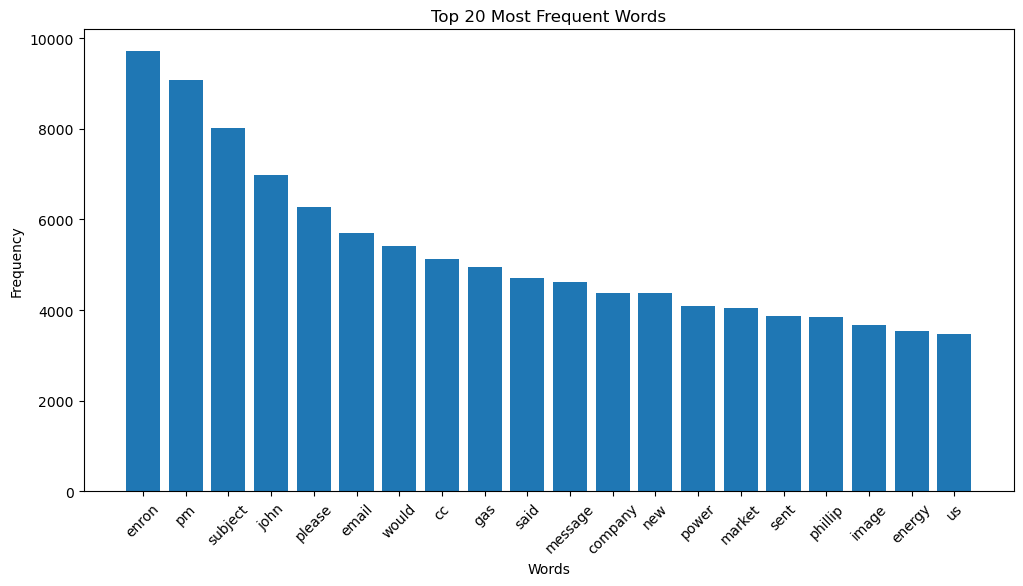

In [ ]:
word_counts = Counter(tokens)

top_20 = word_counts.most_common(20)

words = [word for word, count in top_20]
counts = [count for word, count in top_20]

plt.figure(figsize=(12, 6))
plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

##### The word “enron” has the highest frequency, followed by “pm” and “subject”, showing common email-related terminology. Words such as “email,” “message,” “company,” and “power” also occur frequently in the corpus. The frequency gradually decreases across the top 20 words, indicating that a few words dominate the email vocabulary. Overall, the chart reflects the business and communication-oriented nature of the Enron email dataset.

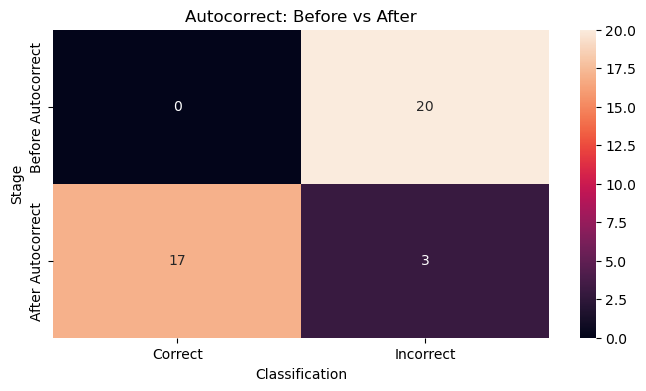

In [ ]:
before_correct = 0
before_incorrect = len(results_df)

after_correct = results_df["Correct"].sum()
after_incorrect = (~results_df["Correct"]).sum()

data = [
    [before_correct, before_incorrect],
    [after_correct, after_incorrect]
]

plt.figure(figsize=(8, 4))

sns.heatmap(
    data,
    annot=True,
    fmt="d",
    xticklabels=["Correct", "Incorrect"],
    yticklabels=["Before Autocorrect", "After Autocorrect"]
)

plt.title("Autocorrect: Before vs After")
plt.xlabel("Classification")
plt.ylabel("Stage")

plt.show()

##### The autocorrect system successfully corrected 17 out of 20 misspelled words, while 3 remained incorrect.
##### Before autocorrection, all 20 words were incorrect; after correction, 85% were corrected successfully.
##### This indicates that the autocorrect model performs well, but some spelling errors still require improvement.

#  Discussion: what are the limitations of your implementation vs. production systems like Google Keyboard?

##### Our implementation demonstrates basic autocomplete and autocorrect using frequency-based n-grams and edit-distance/spell-checking, but it has several limitations compared with production systems such as Google Keyboard (Gboard).
##### 1.Limited context: Our bigram/trigram model considers only 1–2 previous words, while production systems use much richer context to understand the meaning of a sentence.
##### 2.Frequency-based predictions: Our autocomplete mainly depends on word frequency. It may fail when encountering new words, uncommon phrases, names, or slang.
##### 3.No deep language understanding: Our model does not truly understand sentence meaning or context. Modern keyboard systems use advanced machine-learning/neural models to make context-aware predictions.
##### 4.Limited autocorrection: pyspellchecker mainly focuses on spelling similarity and dictionary words. It may not correctly handle abbreviations, technical terms, names, or context-dependent mistakes.
##### 5.Small dataset: We used a subset of the Enron email corpus for experimentation, whereas production systems can learn from much larger and more diverse language data.
##### 6.No personalization: Our system does not learn an individual user's writing style, frequently used words, or preferences.
##### 7.Performance: Our Python implementation can become slow when processing thousands or millions of emails because each text requires preprocessing and prediction.
##### 8.No multilingual support: Our implementation primarily works with English, whereas production keyboards support many languages and can switch between languages.

## Conclusion:
#### Overall, our implementation is useful for understanding the fundamentals of NLP-based autocomplete and autocorrect, but production systems are much more sophisticated. Systems such as Google Keyboard combine large-scale datasets, neural language models, personalization, multilingual processing, and optimized algorithms to provide faster and more context-aware predictions.